# AusGrid PV Data Quality Assessment for AS/NZS 4777.2 Volt-Watt and Volt-VAr

**Set-points used throughout (Tables 3.5–3.7):**

| Volt-Watt (Table 3.6) | value | | Volt-VAr (Table 3.7) | value |
|---|---|---|---|---|
| V_W1 | 253 V → 100% S_rated | | V_V1 | 207 V → 44% supplying |
| V_W2 | 260 V → 20% S_rated  | | V_V2 | 220 V → 0% |
| | | | V_V3 | 240 V → 0% |
| | | | V_V4 | 258 V → 60% absorbing |

Volt-VAr **0% deadband is 220–240 V**. Both modes are enabled by default and
**operate concurrently** (clause 3.3.2.1), so V-W ramp (253–260 V) and V-VAr
absorbing ramp (240–258 V) overlap between 253–258 V. Response timing (Table 3.5)
is ≤1 s commence / ≤10 s complete. **finer than this 5-min data**, so fast events
are under-resolved (a methods caveat, surfaced in §5.2/§7).

This notebook is **schema-adaptive**: checks for absent columns (frequency, energy,
CSIP/export-limit) are skipped with an explicit *NOT PRESENT* note rather than
assumed or crashing.


## 1. Setup, imports & AS/NZS 4777.2.2020 constants

In [14]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.simplefilter("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [15]:
# AS/NZS 4777.2:2020 Australia A default set-points (verified vs Tables 3.6/3.7)
AS4777 = {
    "Vnom": 230.0,
    # Volt-Watt (Table 3.6): P cap is % of S_rated
    "VW1": 253.0,   # 100% S_rated
    "VW2": 260.0,   #  20% S_rated
    # Volt-VAr (Table 3.7): Q level is % of S_rated
    "VV1": 207.0,   # 44% supplying
    "VV2": 220.0,   #  0%
    "VV3": 240.0,   #  0%   (220-240 = 0% deadband)
    "VV4": 258.0,   # 60% absorbing
    "VW_minP_pct": 20.0,
    "VV_supply_pct": 44.0,
    "VV_absorb_pct": 60.0,
}
# Min rows in a voltage zone (per site) before we treat a curve as "testable"
MIN_ZONE_SAMPLES = 200

In [ ]:
# --- Load data: reuse `combined` from the loader, else read the Parquet -------
PARQUET_IN = Path(r"C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\AUSGrid\ausgrid_pv_combined.parquet")
try:
    df = combined.copy()                       # noqa: F821  (loader notebook)
    print("Using in-memory `combined`.")
except NameError:
    df = pd.read_parquet(PARQUET_IN, engine="pyarrow")
    print(f"Loaded from {PARQUET_IN}")
print(f"{df.shape[0]:,} rows x {df.shape[1]} cols")
df.head()


In [ ]:
df[:50][df["Vphase"] == "A"]

C:\Users\z3553082\AppData\Local\Temp\ipykernel_40232\3476543244.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[:50][df["Vphase"] == "A"]


,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file
2,810813941,2025-04-02 09:40:00,A,235.7327,2.6491,-112.3144,607.5186,2025-04,jm_unswnmisapr25
4,810813941,2025-04-02 09:45:00,A,234.5577,2.3997,-91.8936,551.3614,2025-04,jm_unswnmisapr25
6,810813941,2025-04-02 09:50:00,A,235.5368,0.4044,-91.8936,25.5260,2025-04,jm_unswnmisapr25
10,810813941,2025-04-02 09:55:00,A,237.6703,0.4044,-91.8936,25.5260,2025-04,jm_unswnmisapr25
12,810813941,2025-04-02 10:00:00,A,238.2269,0.4044,-91.8936,25.5260,2025-04,jm_unswnmisapr25
17,810813941,2025-04-02 10:05:00,A,238.4433,0.4535,-96.9988,45.9468,2025-04,jm_unswnmisapr25
19,810813941,2025-04-02 10:10:00,A,239.1751,0.4535,-96.9988,40.8416,2025-04,jm_unswnmisapr25
21,810813941,2025-04-02 10:15:00,A,239.2369,0.4535,-96.9988,45.9468,2025-04,jm_unswnmisapr25
25,810813941,2025-04-02 10:20:00,A,239.4534,0.4535,-96.9988,40.8416,2025-04,jm_unswnmisapr25
27,810813941,2025-04-02 10:25:00,A,239.8038,0.4535,-96.9988,40.8416,2025-04,jm_unswnmisapr25


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303647633 entries, 0 to 303647632
Data columns (total 9 columns):
 #   Column       Dtype         
---  ------       -----         
 0   serial       int64         
 1   MeasureTime  datetime64[us]
 2   Vphase       category      
 3   Volts        float64       
 4   Curr         float64       
 5   ReactPow     float64       
 6   ActivePow    float64       
 7   month        category      
 8   source_file  str           
dtypes: category(2), datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 20.9 GB


In [ ]:
# Total sites (unique serials)
df['serial'].nunique()

1342

In [ ]:
# Column registry: classify the physical role of each column
SITE_COL, TIME_COL, PHASE_COL = "serial", "MeasureTime", "Vphase"

def first_present(*names):
    low = {c.lower(): c for c in df.columns}
    for n in names:
        if n.lower() in low:
            return low[n.lower()]
    return None

ROLES = {
    "voltage":        first_present("Volts", "voltage", "v"),
    "current":        first_present("Curr", "current", "i"),
    "active_power":   first_present("ActivePow", "active_power", "p"),
    "reactive_power": first_present("ReactPow", "reactive_power", "q"),
    # spec'd-but-likely-absent:
    "frequency":      first_present("Freq", "frequency", "hz"),
    "energy_cum":     first_present("energy", "wh", "cum_energy", "kwh"),
    "export_limit":   first_present("csip_opmod_exp_lim", "export_limit", "exp_lim"),
    "nameplate":      first_present("s_rated", "rating", "nameplate", "capacity_va"),
}
present = {k: v for k, v in ROLES.items() if v}
absent  = [k for k, v in ROLES.items() if not v]
print("PRESENT:")
for k, v in present.items():
    print(f"  {k:14s} -> {v}")
print("ABSENT (checks skipped with a note):", ", ".join(absent))


PRESENT:
  voltage        -> Volts
  current        -> Curr
  active_power   -> ActivePow
  reactive_power -> ReactPow
ABSENT (checks skipped with a note): frequency, energy_cum, export_limit, nameplate


In [ ]:
# Helpers: assign each voltage reading to a Volt-Watt / Volt-VAr zone
def vw_zone(v):
    """Volt-Watt operating zone (Australia A)."""
    return np.select(
        [v < AS4777["VW1"], v < AS4777["VW2"]],
        ["<V_W1 (100% allowed)", "V_W1-V_W2 ramp (253-260)"],
        default=">=V_W2 (cap 20%)",
    )

def vvar_zone(v):
    """Volt-VAr operating zone (Australia A)."""
    return np.select(
        [v < AS4777["VV1"],
         v < AS4777["VV2"],
         v < AS4777["VV3"],
         v < AS4777["VV4"]],
        ["<=V_V1 supply (44%)",
         "V_V1-V_V2 supply ramp",
         "V_V2-V_V3 deadband (0%)",
         "V_V3-V_V4 absorb ramp"],
        default=">=V_V4 absorb (60%)",
    )

if present.get("voltage"):
    vcol = present["voltage"]
    df["vw_zone"]   = vw_zone(df[vcol].values)
    df["vvar_zone"] = vvar_zone(df[vcol].values)
    print("Volt-Watt zone occupancy (% rows):")
    print((df["vw_zone"].value_counts(normalize=True) * 100).round(2))
    print("\nVolt-VAr zone occupancy (% rows):")
    print((df["vvar_zone"].value_counts(normalize=True) * 100).round(2))


Volt-Watt zone occupancy (% rows):
vw_zone
<V_W1 (100% allowed)       99.8800
V_W1-V_W2 ramp (253-260)    0.1200
>=V_W2 (cap 20%)            0.0000
Name: proportion, dtype: float64

Volt-VAr zone occupancy (% rows):
vvar_zone
V_V3-V_V4 absorb ramp     76.1000
V_V2-V_V3 deadband (0%)   23.1900
<=V_V1 supply (44%)        0.6800
V_V1-V_V2 supply ramp      0.0300
>=V_V4 absorb (60%)        0.0000
Name: proportion, dtype: float64


## 2. Schema & basic statistics

In [ ]:
print("=== dtypes ==="); print(df.dtypes)
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
print("\n=== numeric describe ==="); display(df[num_cols].describe().T)
print("\n=== id / categorical ===")
for c in [SITE_COL, PHASE_COL, "month", "source_file"]:
    if c in df.columns:
        u = df[c].nunique()
        print(f"{c}: {u} unique -> {list(pd.Series(df[c].unique())[:8])}"
              + (" ..." if u > 8 else ""))


=== dtypes ===
serial                  int64
MeasureTime    datetime64[us]
Vphase               category
Volts                 float64
Curr                  float64
ReactPow              float64
ActivePow             float64
month                category
source_file               str
vw_zone                   str
vvar_zone                 str
dtype: object

=== numeric describe ===


,count,mean,std,min,25%,50%,75%,max
serial,"303,647,633.0000","809,265,555.6285","27,034,039.2742","326,214,487.0000","810,660,534.0000","810,824,455.0000","810,977,195.0000","811,513,156.0000"
Volts,"303,647,633.0000",240.6639,20.2943,0.0000,240.1645,242.7515,244.8540,266.3021
Curr,"294,292,213.0000",3.9690,5.3124,0.0000,0.9145,1.9160,4.7428,114.3703
ReactPow,"235,945,498.0000",-19.3912,429.4886,"-8,025.3710",-214.4183,-102.1040,0.0000,"17,168.7813"
ActivePow,"235,945,498.0000",-80.0492,"1,267.9606","-16,254.9500",-96.9988,45.9468,193.9975,"20,895.5742"



=== id / categorical ===
serial: 1342 unique -> [810813941, 810813950, 810814076, 810814128, 810814369, 810814764, 810815271, 810815439] ...
Vphase: 3 unique -> ['C', 'B', 'A']
month: 12 unique -> ['2025-04', '2024-08', '2024-12', '2025-02', '2025-01', '2025-07', '2025-06', '2025-03'] ...
source_file: 12 unique -> ['jm_unswnmisapr25', 'jm_unswnmisaug24', 'jm_unswnmisdec24', 'jm_unswnmisfeb25', 'jm_unswnmisjan25', 'jm_unswnmisjul25', 'jm_unswnmisjun25', 'jm_unswnmismar25'] ...


Null rate (%):
ActivePow     22.2960
ReactPow      22.2960
Curr           3.0810
Vphase         0.0000
MeasureTime    0.0000
serial         0.0000
Volts          0.0000
month          0.0000
source_file    0.0000
vw_zone        0.0000
vvar_zone      0.0000
dtype: float64


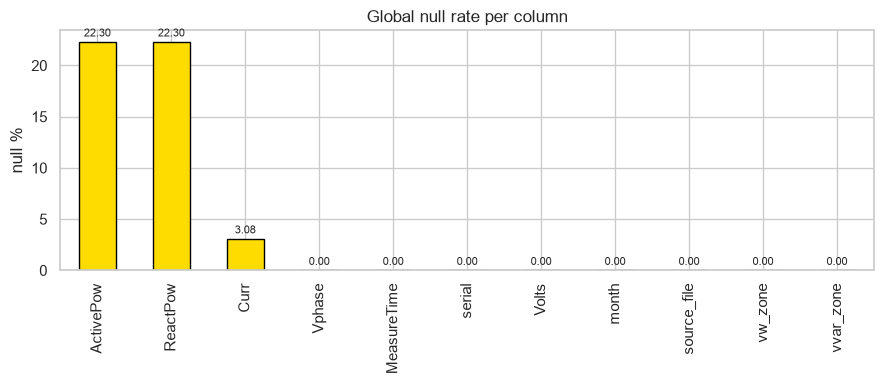

In [ ]:
null_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Null rate (%):"); print(null_pct.round(3))
fig, ax = plt.subplots(figsize=(9, 4))
null_pct.plot(kind="bar", ax=ax, color="#FFDC00", edgecolor="black")
ax.set_ylabel("null %"); ax.set_title("Global null rate per column")
for i, val in enumerate(null_pct):
    ax.text(i, val + 0.3, f"{val:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()


## 3. Temporal integrity
Long format = 3 rows per timestamp (phases A/B/C); cadence 5 min. Checks run
per site on distinct timestamps, with phase-triple completeness tracked separately.

In [ ]:
CADENCE = pd.Timedelta(minutes=5)
grid = (df[[SITE_COL, TIME_COL]].drop_duplicates()
        .sort_values([SITE_COL, TIME_COL]).reset_index(drop=True))

def site_span_stats(g):
    t = g[TIME_COL]
    span = t.max() - t.min()
    expected = int(span / CADENCE) + 1 if len(t) > 1 else 1
    return pd.Series({"first": t.min(), "last": t.max(),
                      "expected_intervals": expected,
                      "actual_intervals": t.nunique(),
                      "completeness_%": 100 * t.nunique() / expected if expected else np.nan})

site_time = grid.groupby(SITE_COL).apply(site_span_stats, include_groups=False)
print("Per-site temporal completeness (head):"); display(site_time.head(10))
print("completeness_% summary:"); print(site_time["completeness_%"].describe().round(2))


Per-site temporal completeness (head):


,first,last,expected_intervals,actual_intervals,completeness_%
serial,,,,,
326214487,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,105048,99.9315
326214520,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,105048,99.9315
326228801,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,104976,99.8630
326612333,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,104976,99.8630
361431370,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,104976,99.8630
810014969,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,104976,99.8630
810014979,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,104976,99.8630
810015442,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,104976,99.8630
810017544,2024-08-01 00:00:00,2025-07-31 23:55:00,105120,105048,99.9315


completeness_% summary:
count   1,342.0000
mean       99.8800
std         0.1700
min        94.9100
25%        99.8600
50%        99.8600
75%        99.9300
max       100.0000
Name: completeness_%, dtype: float64


In [ ]:
# phase-triple completeness + exact duplicates
triple = df.groupby([SITE_COL, TIME_COL], observed=True).size()
print("rows-per-(site,timestamp):"); print(triple.value_counts().sort_index())
not_three = triple[triple != 3]
print(f"\n(site,timestamp) groups without exactly 3 phases: {len(not_three):,}")
dup = df.duplicated(subset=[SITE_COL, TIME_COL, PHASE_COL], keep=False)
print(f"exact duplicate (serial,timestamp,phase) rows: {dup.sum():,}")


rows-per-(site,timestamp):
1        62974495
2         7835887
3        68007567
4         1161703
9             579
16              3
24           2232
32           8049
48          74178
64              1
100           609
121            85
162           578
243          3400
768             1
3000           92
3888            3
7203            1
8192            1
30000         372
Name: count, dtype: int64

(site,timestamp) groups without exactly 3 phases: 72,062,269
exact duplicate (serial,timestamp,phase) rows: 20,982,983


In [ ]:
dup

NameError: name 'dup' is not defined

interval minutes (top):
MeasureTime
5.0000      140066522
365.0000         1627
725.0000          184
370.0000           34
360.0000           21
405.0000            5
300.0000            5
375.0000            5
Name: count, dtype: int64

gaps > 10 min: 1,972


,serial,gap_start,gap_end,gap_minutes
1571,811020106,2024-10-22 03:15:00,2024-11-09 05:30:00,"26,055.0000"
1121,810871559,2025-04-09 18:45:00,2025-04-21 06:20:00,"16,535.0000"
254,810374480,2025-04-15 02:55:00,2025-04-15 22:25:00,"1,170.0000"
1390,810953174,2025-04-20 08:30:00,2025-04-21 02:35:00,"1,085.0000"
1742,811113898,2025-04-20 10:20:00,2025-04-21 04:20:00,"1,080.0000"
1321,810944047,2025-04-15 14:00:00,2025-04-16 03:50:00,830.0000
1339,810944086,2025-04-15 15:25:00,2025-04-16 04:20:00,775.0000
610,810689644,2025-04-15 14:30:00,2025-04-16 02:45:00,735.0000


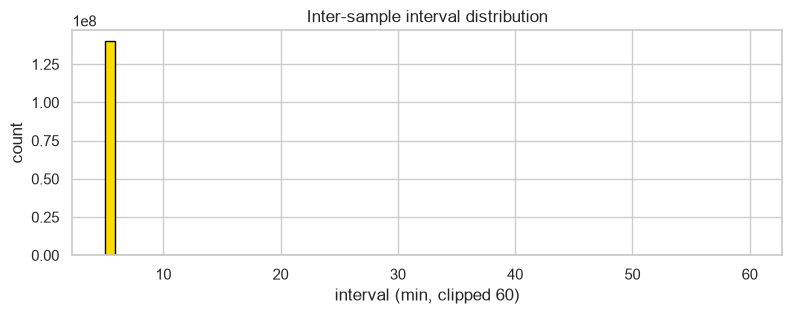

In [ ]:
# delta distribution + gap detection
deltas_all, gap_rows = [], []
for s, g in grid.groupby(SITE_COL, observed=True):
    ts = g[TIME_COL].sort_values(); d = ts.diff().dropna()
    deltas_all.append(d)
    big = d[d > 2 * CADENCE]
    if len(big):
        gap_rows.append(pd.DataFrame({SITE_COL: s,
            "gap_start": ts.shift().loc[big.index].values,
            "gap_end": ts.loc[big.index].values,
            "gap_minutes": big.dt.total_seconds() / 60}))
deltas_all = pd.concat(deltas_all) if deltas_all else pd.Series([], dtype="timedelta64[ns]")
gaps = pd.concat(gap_rows, ignore_index=True) if gap_rows else pd.DataFrame(columns=[SITE_COL, "gap_minutes"])
print("interval minutes (top):"); print((deltas_all.dt.total_seconds()/60).round(2).value_counts().head(8))
print(f"\ngaps > 10 min: {len(gaps):,}")
if len(gaps): display(gaps.sort_values("gap_minutes", ascending=False).head(8))
if len(deltas_all):
    fig, ax = plt.subplots(figsize=(8, 3.3))
    ax.hist((deltas_all.dt.total_seconds()/60).clip(upper=60), bins=60, color="#FFDC00", edgecolor="black")
    ax.set_xlabel("interval (min, clipped 60)"); ax.set_ylabel("count")
    ax.set_title("Inter-sample interval distribution"); plt.tight_layout(); plt.show()


## 4. Column-by-column quality assessment

### 4.1 Voltage (`Volts`) banded against both Volt-Watt and Volt-VAr set-points

Volts: min=0.00 max=266.30 mean=240.66
  <=0 V: 2,061,922   >300 V (implausible): 0

operating-band occupancy (% of phase-readings):
  <207                                      : 0.6835%
  207-220 (VVAr supply ramp)                : 0.0310%
  220-240 (VVAr deadband 0%)                : 23.1891%
  240-253 (VVAr absorb ramp)                : 75.9791%
  253-258 (VWatt ramp + VVAr absorb)        : 0.1170%
  258-260 (VWatt ramp; VVAr hold 60%)       : 0.0004%
  >=260 (VWatt cap 20%)                     : 0.0001%


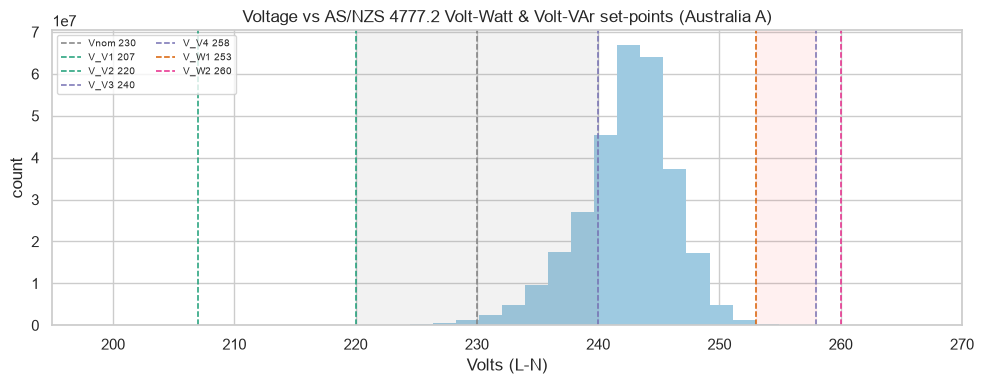

In [ ]:
vcol = present.get("voltage")
if not vcol:
    print("NOT PRESENT: voltage. neither Volt-Watt nor Volt-VAr analysis possible.")
else:
    v = df[vcol]
    print(f"{vcol}: min={v.min():.2f} max={v.max():.2f} mean={v.mean():.2f}")
    print(f"  <=0 V: {(v<=0).sum():,}   >300 V (implausible): {(v>300).sum():,}")

    # full operating-band occupancy (V-W and V-VAr breakpoints combined)
    edges = [0, AS4777["VV1"], AS4777["VV2"], AS4777["VV3"], AS4777["VW1"],
             AS4777["VV4"], AS4777["VW2"], 1e9]
    labels = [
              "<207", 
              "207-220 (VVAr supply ramp)", 
              "220-240 (VVAr deadband 0%)",
              "240-253 (VVAr absorb ramp)", 
              "253-258 (VWatt ramp + VVAr absorb)",
              "258-260 (VWatt ramp; VVAr hold 60%)", 
              ">=260 (VWatt cap 20%)"
              ]
    occ = pd.cut(v, bins=edges, labels=labels, right=False).value_counts(normalize=True).reindex(labels) * 100
    print("\noperating-band occupancy (% of phase-readings):")
    for k, val in occ.items():
        print(f"  {k:42s}: {val:6.4f}%")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(v.dropna(), bins=140, color="#9ecae1", edgecolor="none")
    # zone shading
    ax.axvspan(AS4777["VV2"], AS4777["VV3"], color="grey", alpha=0.10)   # deadband
    ax.axvspan(AS4777["VW1"], AS4777["VV4"], color="red", alpha=0.06)    # concurrent overlap
    for x, lbl, c in [(AS4777["Vnom"], "Vnom 230", "grey"),
                      (AS4777["VV1"], "V_V1 207", "#1b9e77"),
                      (AS4777["VV2"], "V_V2 220", "#1b9e77"),
                      (AS4777["VV3"], "V_V3 240", "#7570b3"),
                      (AS4777["VV4"], "V_V4 258", "#7570b3"),
                      (AS4777["VW1"], "V_W1 253", "#d95f02"),
                      (AS4777["VW2"], "V_W2 260", "#e7298a")]:
        ax.axvline(x, ls="--", lw=1.1, color=c, label=lbl)
    ax.set_xlim(195, 270); ax.set_xlabel("Volts (L-N)"); ax.set_ylabel("count")
    ax.set_title("Voltage vs AS/NZS 4777.2 Volt-Watt & Volt-VAr set-points (Australia A)")
    ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()


### 4.2 Active power (`ActivePow`) sign, range, quantisation (Volt-Watt input)

In [ ]:
pcol = present.get("active_power")
if not pcol:
    print("NOT PRESENT: active power. Volt-Watt analysis impossible.")
else:
    p = df[pcol]
    print(f"{pcol}: min={p.min():.3f} max={p.max():.3f} mean={p.mean():.3f} (per-phase W)")
    print(f"  P<0 (import on PV-only feed): {(p<0).sum():,} ({100*(p<0).mean():.3f}%)")
    print(f"  P==0: {(p==0).sum():,} ({100*(p==0).mean():.3f}%)   >10kW/phase: {(p>10_000).sum():,}")
    u = np.sort(p.dropna().unique())
    if len(u) > 3:
        d = np.diff(u); print(f"  quantisation step ~ {np.median(d[d>0]):.4f} W ({len(u):,} unique)")
        print("  -> coarse P resolution limits fine Volt-Watt curtailment-gradient detection.")


ActivePow: min=-16254.950 max=20895.574 mean=-80.049 (per-phase W)
  P<0 (import on PV-only feed): 67,430,608 (22.207%)
  P==0: 19,796,917 (6.520%)   >10kW/phase: 32,908
  quantisation step ~ 5.1052 W (5,511 unique)
  -> coarse P resolution limits fine Volt-Watt curtailment-gradient detection.


### 4.3 Reactive power (`ReactPow`) sign & quantisation (Volt-VAr input)

In [ ]:
qcol = present.get("reactive_power")
if not qcol:
    print("NOT PRESENT: reactive power. Volt-VAr analysis impossible.")
else:
    q = df[qcol]
    print(f"{qcol}: min={q.min():.3f} max={q.max():.3f} mean={q.mean():.3f} (per-phase VAr)")
    print(f"  %negative: {100*(q<0).mean():.2f}  %positive: {100*(q>0).mean():.2f}  %zero: {100*(q==0).mean():.2f}")
    u = np.sort(q.dropna().unique())
    if len(u) > 3:
        d = np.diff(u); print(f"  quantisation step ~ {np.median(d[d>0]):.4f} VAr ({len(u):,} unique)")
    print("  NOTE: sign convention must be confirmed with AusGrid (negative = absorbing?).")
    print("        Volt-VAr adherence (incl. the 220-240 V deadband test) is in Section 5.4.")


ReactPow: min=-8025.371 max=17168.781 mean=-19.391 (per-phase VAr)
  %negative: 55.06  %positive: 18.07  %zero: 4.57
  quantisation step ~ 5.1052 VAr (2,434 unique)
  NOTE: sign convention must be confirmed with AusGrid (negative = absorbing?).
        Volt-VAr adherence (incl. the 220-240 V deadband test) is in Section 5.4.


### 4.4 Current (`Curr`)

In [ ]:
ccol = present.get("current")
if not ccol:
    print("NOT PRESENT: current.")
else:
    c = df[ccol]
    print(f"{ccol}: min={c.min():.3f} max={c.max():.3f} mean={c.mean():.3f} A")
    print(f"  negative: {(c<0).sum():,}   >100 A/phase: {(c>100).sum():,}")


Curr: min=0.000 max=114.370 mean=3.969 A
  negative: 0   >100 A/phase: 13


### 4.5 Phase (`Vphase`) & site id (`serial`)

In [ ]:
if PHASE_COL in df.columns:
    print("phase counts:", df[PHASE_COL].value_counts(dropna=False).to_dict())
    bad = set(df[PHASE_COL].dropna().unique()) - {"A", "B", "C"}
    if bad: print("  [warn] unexpected phase labels:", bad)
if SITE_COL in df.columns:
    print(f"serial: {df[SITE_COL].nunique():,} sites; dtype={df[SITE_COL].dtype}")
    print("  serial length dist:", df[SITE_COL].astype(str).str.len().value_counts().to_dict())


phase counts: {'A': 149021920, 'B': 81319785, 'C': 73305928}
serial: 1,342 sites; dtype=int64
  serial length dist: {9: 303647633}


### 4.6 Timestamp (`MeasureTime`) parse integrity & timezone caveat

In [ ]:
t = df[TIME_COL]
print(f"{TIME_COL}: dtype={t.dtype}  NaT={t.isna().sum():,}")
print(f"  range: {t.min()} -> {t.max()}")
print(f"  seconds!=0: {(t.dt.second!=0).sum():,}   minute not mult of 5: {(t.dt.minute%5!=0).sum():,}")
print("  WARNING: 'Z'/UTC label but generation sits in local daylight - see Section 5.2.")


MeasureTime: dtype=datetime64[us]  NaT=0
  range: 2024-08-01 00:00:00 -> 2025-07-31 23:55:00
  seconds!=0: 0   minute not mult of 5: 0


### 4.7 Spec'd-but-absent signals (frequency / energy / CSIP / nameplate)

In [ ]:
def absence_note(role, why):
    if present.get(role):
        print(f"PRESENT: {role} -> {present[role]}"); return
    print(f"NOT PRESENT: {role}\n   impact: {why}\n")

absence_note("frequency",
    "no Hz -> no frequency ride-through / ROCOF check.")
absence_note("energy_cum",
    "no cumulative energy -> derive interval energy from 5-min average power if needed.")
absence_note("export_limit",
    "no CSIP-AUS / export-limit -> no flexible-export-limit / DOE / EBM compliance.")
absence_note("nameplate",
    "no S_rated -> Volt-Watt 100%/20% caps and Volt-VAr 44%/60% levels cannot be "
    "expressed as % of rating. DIRECTION/sign checks still work; MAGNITUDE checks need rating.")


NOT PRESENT: frequency
   impact: no Hz -> no frequency ride-through / ROCOF check.

NOT PRESENT: energy_cum
   impact: no cumulative energy -> derive interval energy from 5-min average power if needed.

NOT PRESENT: export_limit
   impact: no CSIP-AUS / export-limit -> no flexible-export-limit / DOE / EBM compliance.

NOT PRESENT: nameplate
   impact: no S_rated -> Volt-Watt 100%/20% caps and Volt-VAr 44%/60% levels cannot be expressed as % of rating. DIRECTION/sign checks still work; MAGNITUDE checks need rating.



In [ ]:
df

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file,vw_zone,vvar_zone
0,810813941,2025-04-02 09:40:00,C,240.0511,1.7195,-193.9975,265.4703,2025-04,jm_unswnmisapr25,<V_W1 (100% allowed),V_V3-V_V4 absorb ramp
1,810813941,2025-04-02 09:40:00,B,233.8260,0.4119,-86.7884,35.7364,2025-04,jm_unswnmisapr25,<V_W1 (100% allowed),V_V2-V_V3 deadband (0%)
2,810813941,2025-04-02 09:40:00,A,235.7327,2.6491,-112.3144,607.5186,2025-04,jm_unswnmisapr25,<V_W1 (100% allowed),V_V2-V_V3 deadband (0%)
3,810813941,2025-04-02 09:45:00,C,239.8347,1.7611,-193.9975,270.5755,2025-04,jm_unswnmisapr25,<V_W1 (100% allowed),V_V2-V_V3 deadband (0%)
4,810813941,2025-04-02 09:45:00,A,234.5577,2.3997,-91.8936,551.3614,2025-04,jm_unswnmisapr25,<V_W1 (100% allowed),V_V2-V_V3 deadband (0%)
...,...,...,...,...,...,...,...,...,...,...,...
303647628,811513156,2024-09-30 23:45:00,A,242.2774,10.6873,342.0482,"-2,557.7040",2024-09,jm_unswnmissep24,<V_W1 (100% allowed),V_V3-V_V4 absorb ramp
303647629,811513156,2024-09-30 23:50:00,B,240.5149,0.0000,0.0000,0.0000,2024-09,jm_unswnmissep24,<V_W1 (100% allowed),V_V3-V_V4 absorb ramp
303647630,811513156,2024-09-30 23:50:00,A,240.5149,10.8498,-76.5780,"-2,588.3355",2024-09,jm_unswnmissep24,<V_W1 (100% allowed),V_V3-V_V4 absorb ramp
303647631,811513156,2024-09-30 23:55:00,A,240.1130,11.5224,51.0520,"-2,751.7017",2024-09,jm_unswnmissep24,<V_W1 (100% allowed),V_V3-V_V4 absorb ramp


## 5. Cross-column physical plausibility & 4777.2 curve adherence

### 5.1 Apparent-power consistency: V·I vs √(P²+Q²)

In [ ]:
need = all(present.get(r) for r in ("voltage", "current", "active_power", "reactive_power"))
if not need:
    print("Skipped: needs V, I, P, Q.")
else:
    s_vi = df[present["voltage"]] * df[present["current"]]
    s_pq = np.sqrt(df[present["active_power"]]**2 + df[present["reactive_power"]]**2)
    ratio = (s_pq / s_vi).replace([np.inf, -np.inf], np.nan)
    print("S_pq / S_vi:"); print(ratio.describe(percentiles=[.01,.05,.5,.95,.99]).round(3))
    print(f"  ratio>1.05 (non-physical fundamental): {(ratio>1.05).sum():,} ({100*(ratio>1.05).mean():.3f}%)")
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.hist(ratio.dropna().clip(0, 1.5), bins=80, color="#9ecae1", edgecolor="none")
    ax.axvline(1.0, color="#d95f02", ls="--", label="ideal=1"); ax.legend(fontsize=8)
    ax.set_xlabel("S_pq / S_vi"); ax.set_title("Apparent-power consistency"); plt.tight_layout(); plt.show()


### 5.2 Timezone diagnostic: Generation vs local hour
PV active power must be ~0 during local night. We bin mean site power by hour under
two label interpretations; the one with ~0 night generation is correct.

In [ ]:
LOCAL_TZ = "Australia/Sydney"
pcol = present.get("active_power")
if not pcol:
    print("Skipped: no active power.")
else:
    tot = (df.groupby([SITE_COL, TIME_COL], observed=True)[pcol].sum().rename("P").reset_index())
    tA = pd.to_datetime(tot[TIME_COL]).dt.tz_localize("UTC").dt.tz_convert(LOCAL_TZ)  # label=UTC
    tB = pd.to_datetime(tot[TIME_COL])                                                # label already local
    byA = tot.assign(h=tA.dt.hour).groupby("h")["P"].mean()
    byB = tot.assign(h=tB.dt.hour).groupby("h")["P"].mean()
    fig, ax = plt.subplots(figsize=(9, 3.4))
    ax.plot(byA.index, byA.values, marker="o", label="A: label=UTC -> local")
    ax.plot(byB.index, byB.values, marker="s", label="B: label already local")
    ax.axvspan(0, 5, color="grey", alpha=0.12); ax.axvspan(21, 24, color="grey", alpha=0.12)
    ax.set_xlabel("local hour"); ax.set_ylabel("mean site P (W)")
    ax.set_title("Which interpretation puts PV generation in daylight?"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    night = lambda s: s.reindex(range(24)).loc[list(range(0,5))+list(range(21,24))].mean()
    print(f"mean night-hour generation (should be ~0): A(UTC)={night(byA):.1f} W   B(local)={night(byB):.1f} W")


### 5.3 Standby / tare check (P==0)

In [ ]:
pcol = present.get("active_power")
if pcol and present.get("current"):
    z = df[df[pcol] == 0]
    if len(z):
        cols = [c for c in [present.get("current"), present.get("reactive_power")] if c]
        print(f"P==0 rows: {len(z):,}. Residual I/Q at zero output:"); display(z[cols].describe().T)
        print("  Non-zero residuals at P=0 => standby/tare; exclude from generation stats,"
              "  do NOT read as curtailment.")


### 5.4. Volt-VAr curve adherence (core V-VAr DQ test)
Under Australia A, reactive power should: **supply** below V_V1 (207), be **~0 in the
220–240 V deadband**, and **absorb** above V_V3 (240). We (a) bin mean Q by voltage and
overlay the expected curve shape, (b) compare the dominant Q sign in the supply vs
absorb zones to infer the sign convention and whether the fleet shows true Volt-VAr or
a fixed power factor, and (c) test the deadband.

In [ ]:
vcol, qcol = present.get("voltage"), present.get("reactive_power")
if not (vcol and qcol):
    print("Skipped: needs voltage and reactive power.")
else:
    v, q = df[vcol], df[qcol]
    # (a) binned mean Q vs voltage
    vb = pd.cut(v, bins=np.arange(200, 266, 1))
    binned = q.groupby(vb, observed=True).mean()
    centers = [iv.mid for iv in binned.index]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(centers, binned.values, marker=".", lw=1.2, color="#2166ac", label="measured mean Q")
    ax.axhline(0, color="black", lw=0.8)
    ax.axvspan(AS4777["VV2"], AS4777["VV3"], color="grey", alpha=0.12, label="0% deadband 220-240")
    for x, c in [(AS4777["VV1"], "#1b9e77"), (AS4777["VV2"], "#1b9e77"),
                 (AS4777["VV3"], "#7570b3"), (AS4777["VV4"], "#7570b3")]:
        ax.axvline(x, ls="--", lw=1.0, color=c)
    ax.set_xlabel("Volts (L-N)"); ax.set_ylabel("mean ReactPow (VAr)")
    ax.set_title("Volt-VAr characteristic: measured mean reactive power vs voltage")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

    # (b) dominant sign in supply vs absorb zones -> infer convention / behaviour
    supply = q[v <= AS4777["VV1"]]
    absorb = q[v >= AS4777["VV3"]]
    dead   = q[(v >= AS4777["VV2"]) & (v < AS4777["VV3"])]
    def dom(s):
        if len(s) < 30: return "insufficient", np.nan
        frac_neg = (s < 0).mean()
        return ("mostly negative" if frac_neg > 0.6 else
                "mostly positive" if frac_neg < 0.4 else "mixed"), s.median()
    s_sign, s_med = dom(supply); a_sign, a_med = dom(absorb)
    print(f"supply zone (V<=207): n={len(supply):,}  {s_sign}  median={s_med:.1f} VAr")
    print(f"deadband  (220-240): n={len(dead):,}  median|Q|={dead.abs().median():.1f} VAr"
          if len(dead) else "deadband: no samples")
    print(f"absorb zone (V>=240): n={len(absorb):,}  {a_sign}  median={a_med:.1f} VAr")

    if s_sign.startswith("mostly") and a_sign.startswith("mostly") and s_sign != a_sign:
        print("\n  => sign FLIPS supply<->absorb: consistent with TRUE Volt-VAr response.")
    elif s_sign == a_sign and s_sign.startswith("mostly"):
        print("\n  => same sign in BOTH zones: looks like a FIXED power factor / offset,"
              "\n     NOT a true Volt-VAr response (or an unresolved sign convention).")
    else:
        print("\n  => inconclusive (insufficient samples in one or both zones).")

    # (c) deadband cleanliness: deadband |Q| relative to absorb |Q|
    if len(dead) and len(absorb):
        ratio = dead.abs().median() / max(absorb.abs().median(), 1e-9)
        print(f"\n  deadband |Q| / absorb |Q| ratio = {ratio:.2f} "
              f"({'~0 -> clean deadband (true V-VAr)' if ratio < 0.3 else 'elevated -> non-zero reactive in deadband'})")


### 5.5. Volt-Watt observability (can curtailment be observed?)
Volt-Watt curtailment only manifests above V_W1 (253 V). We report how much data lands
in the ramp/cap zones, and (qualitatively) whether active power trends down as voltage
rises there. Magnitude (% of S_rated) needs the missing nameplate (§4.7).

In [ ]:
vcol, pcol = present.get("voltage"), present.get("active_power")
if not (vcol and pcol):
    print("Skipped: needs voltage and active power.")
else:
    v, p = df[vcol], df[pcol]
    n_ramp = ((v >= AS4777["VW1"]) & (v < AS4777["VW2"])).sum()
    n_cap  = (v >= AS4777["VW2"]).sum()
    print(f"rows in V-W ramp (253-260 V): {n_ramp:,} ({100*n_ramp/len(v):.3f}%)")
    print(f"rows at/above V_W2 (>=260 V): {n_cap:,} ({100*n_cap/len(v):.3f}%)")
    if n_ramp + n_cap == 0:
        print("  -> fleet essentially never enters the Volt-Watt zone in this period:")
        print("     Volt-Watt COMPLIANCE is largely UNOBSERVABLE here (good for V-VAr focus).")
    else:
        # qualitative: mean P in/above ramp vs below (active-power-weighted view is noisy at 1-min)
        below = p[v < AS4777["VW1"]].mean()
        inramp = p[(v >= AS4777["VW1"]) & (v < AS4777["VW2"])].mean()
        print(f"  mean P below 253 V: {below:.1f} W   |  mean P in 253-260 V ramp: {inramp:.1f} W")
        print("  (interpret with care: needs S_rated to confirm true curtailment vs low irradiance)")


### 5.6. Volt-VAr direction correlation (quick global check)

In [ ]:
if present.get("voltage") and present.get("reactive_power"):
    vcol, qcol = present["voltage"], present["reactive_power"]
    print(f"corr(Volts, ReactPow) overall = {df[vcol].corr(df[qcol]):.3f}")
    by_ph = df.groupby(PHASE_COL, observed=True).apply(
        lambda g: g[vcol].corr(g[qcol]), include_groups=False)
    print("per-phase:", by_ph.round(3).to_dict())
    print("(negative under 'negative=absorbing' is consistent with absorbing more as V rises)")


## 6. Per-site quality summary + null heatmap (with V-W / V-VAr occupancy)

In [ ]:
signal_cols = [c for c in [present.get(r) for r in
               ("voltage","current","active_power","reactive_power")] if c]
null_by_site = df.groupby(SITE_COL)[signal_cols].apply(lambda g: g.isna().mean()*100)

def site_summary(g):
    out = {"n_rows": len(g)}
    if present.get("voltage"):
        v = g[present["voltage"]]
        out["v_mean"] = v.mean(); out["v_max"] = v.max()
        out["pct_vw_ramp"]  = 100*((v>=AS4777["VW1"])&(v<AS4777["VW2"])).mean()
        out["pct_vw_cap"]   = 100*(v>=AS4777["VW2"]).mean()
        out["pct_vvar_supply"] = 100*(v<=AS4777["VV1"]).mean()
        out["pct_vvar_absorb"] = 100*(v>=AS4777["VV3"]).mean()
        out["pct_deadband"]    = 100*((v>=AS4777["VV2"])&(v<AS4777["VV3"])).mean()
    if present.get("reactive_power"):
        q = g[present["reactive_power"]]
        if present.get("voltage"):
            dead = q[(g[present["voltage"]]>=AS4777["VV2"]) & (g[present["voltage"]]<AS4777["VV3"])]
            out["deadband_med_absQ"] = dead.abs().median() if len(dead) else np.nan
    if present.get("active_power"):
        out["p_max"] = g[present["active_power"]].max()
    return pd.Series(out)

summary = df.groupby(SITE_COL).apply(site_summary, include_groups=False)
summary = summary.join(site_time[["completeness_%","first","last"]], how="left")
print("Per-site summary (head):"); display(summary.head(15))

show = null_by_site.head(60) if len(null_by_site) > 60 else null_by_site
fig, ax = plt.subplots(figsize=(7, max(3, 0.22*len(show))))
sns.heatmap(show, cmap="YlOrRd", vmin=0, vmax=100, cbar_kws={"label":"null %"}, ax=ax)
ax.set_title("Null rate (%) - sites x signals"); ax.set_ylabel("serial"); plt.tight_layout(); plt.show()


## 7. Quality / testability flags (pass-fail per site) + CSV export
Flags include whether each site can support Volt-Watt and Volt-VAr analysis.

In [ ]:
flags = pd.DataFrame(index=summary.index)
flags["completeness_ok"] = summary["completeness_%"].fillna(0) >= 95

if present.get("voltage"):
    bad_v = df.groupby(SITE_COL)[present["voltage"]].apply(lambda s: ((s<=0)|(s>300)).any())
    flags["voltage_physical_ok"] = ~bad_v.reindex(flags.index).fillna(False)
if present.get("active_power"):
    neg_p = df.groupby(SITE_COL)[present["active_power"]].apply(lambda s: (s<0).mean()>0.01)
    flags["active_power_sign_ok"] = ~neg_p.reindex(flags.index).fillna(False)

ph_ok = triple.groupby(level=0).apply(lambda s: (s==3).mean()>=0.95)
flags["phase_triple_ok"] = ph_ok.reindex(flags.index).fillna(False)
flags["low_null_ok"] = null_by_site.max(axis=1).reindex(flags.index).fillna(100) < 5

# --- 4777.2 testability ---------------------------------------------------
def zone_counts(col_ok, mask_fn):
    if not col_ok: return pd.Series(0, index=summary.index)
    return df.groupby(SITE_COL)[present["voltage"]].apply(mask_fn).reindex(summary.index).fillna(0)

if present.get("voltage") and present.get("reactive_power"):
    n_supply = zone_counts(True, lambda s: (s<=AS4777["VV1"]).sum())
    n_absorb = zone_counts(True, lambda s: (s>=AS4777["VV3"]).sum())
    # Volt-VAr testable if both a supply-side and absorb-side population exist
    flags["volt_var_testable"] = (n_absorb >= MIN_ZONE_SAMPLES)  # absorb zone is the active one here
    flags["volt_var_supply_seen"] = (n_supply >= MIN_ZONE_SAMPLES)
if present.get("voltage") and present.get("active_power"):
    n_vw = zone_counts(True, lambda s: (s>=AS4777["VW1"]).sum())
    flags["volt_watt_testable"] = (n_vw >= MIN_ZONE_SAMPLES)

flags["ALL_BASIC_PASS"] = flags[[c for c in flags.columns if c.endswith("_ok")]].all(axis=1)
print("flag pass-rates (% of sites):"); print((flags.mean(numeric_only=True)*100).round(1))
print(f"\nsites passing all BASIC quality checks: {flags['ALL_BASIC_PASS'].sum()} / {len(flags)}")
if "volt_var_testable" in flags:
    print(f"sites where Volt-VAr is testable: {flags['volt_var_testable'].sum()} / {len(flags)}")
if "volt_watt_testable" in flags:
    print(f"sites where Volt-Watt is testable: {flags['volt_watt_testable'].sum()} / {len(flags)}")
display(flags.head(15))

OUT_CSV = Path("ausgrid_pv_quality_flags.csv")
flags.join(summary).to_csv(OUT_CSV)
print(f"\nWrote {OUT_CSV.resolve()}")


## Final — Issues & readiness summary for the data provider

**Verdict on fitness:** the data carries the signals needed for **Volt-VAr direction
analysis** (voltage + per-phase reactive power) and the *inputs* for **Volt-Watt**
(voltage + per-phase active power), but several items below must be resolved before
quantitative compliance numbers can be produced.

1. **Reactive sign convention (BLOCKS V-VAr interpretation).** Confirm whether negative
   `ReactPow` = absorbing. §5.4 infers this from the supply-vs-absorb sign flip; if no
   flip is seen, the fleet may be on a **fixed power factor**, not true Volt-VAr.

2. **Deadband behaviour (key V-VAr finding).** Australia A specifies **0% reactive in
   220–240 V**. §5.4/§6 report the measured median |Q| there per site — non-zero values
   indicate either a non-default curve, fixed PF, or a sign/offset issue.

3. **Nameplate / S_rated (BLOCKS magnitude checks).** Needed to express the Volt-Watt
   100%/20% caps and Volt-VAr 44%/60% levels. Direction/sign checks work without it;
   magnitude compliance does not. Request per-`serial` rating.

4. **Volt-Watt observability.** §5.5 reports ramp-zone (253–260 V) occupancy. If the
   fleet rarely exceeds 253 V, Volt-Watt compliance is largely unobservable in this
   window regardless of data quality — focus may sit with Volt-VAr.

5. **Timezone (`Z` vs local).** §5.2 shows generation aligns with local daylight, not
   UTC — confirm the true timezone before any time-of-day work.

6. **Resolution caveat.** 5-min data is coarser than the standard's 1 s/10 s response
   timing (Table 3.5); fast V-W/V-VAr transients are under-resolved. State in methods.

7. **Power quantisation (~5 W/VAr step) & standby tare** (§4.2/§4.3/§5.3): fine at kW
   scale; exclude P==0 standby residuals from generation stats.


In [ ]:
print("=== machine-generated readiness digest (this run) ===")
print(f"rows {len(df):,} | sites {df[SITE_COL].nunique():,} | "
      f"span {df[TIME_COL].min()} -> {df[TIME_COL].max()}")
print(f"absent spec'd signals: {', '.join(absent) if absent else 'none'}")
if "volt_var_testable" in flags:
    print(f"Volt-VAr testable sites: {flags['volt_var_testable'].sum()}/{len(flags)}")
if "volt_watt_testable" in flags:
    print(f"Volt-Watt testable sites: {flags['volt_watt_testable'].sum()}/{len(flags)}")
if present.get("voltage"):
    v = df[present["voltage"]]
    print(f"voltage occupancy: deadband(220-240)={100*((v>=220)&(v<240)).mean():.1f}%  "
          f"absorb(>=240)={100*(v>=240).mean():.1f}%  VW-ramp(>=253)={100*(v>=253).mean():.1f}%")
